# Regressão linear com PIB e Índice ABCR

Este notebook investiga a relação entre a atividade econômica brasileira e o fluxo de veículos em rodovias pedagiadas.

**Período:** 2006 a 2025  
**PIB:** índice de volume trimestral, sem ajuste sazonal, PIB a preços de mercado, média de 1995 = 100  
**ABCR:** série original do fluxo total de veículos, sem ajuste sazonal, base 1999 = 100

Fontes:
- IBGE — Tabela 1620 do SIDRA: https://sidra.ibge.gov.br/tabela/1620
- ABCR — Índice ABCR: https://melhoresrodovias.org.br/indice-abcr_2/

Os arquivos originais consultados foram preservados na pasta `dados_originais/`.


## 1. Preparação

As séries têm frequências diferentes. O PIB é trimestral e o ABCR é mensal. Para deixar os dois indicadores comparáveis por ano:

- `PIB_indice` = média dos 4 trimestres;
- `ABCR_indice` = média dos 12 meses.

Antes do cálculo das médias, o código verifica se cada ano possui todos os períodos esperados.


In [1]:
from pathlib import Path
from collections import defaultdict
import csv
import statistics
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PASTA_DADOS = Path("dados")
PASTA_RESULTADOS = Path("resultados")
PASTA_RESULTADOS.mkdir(exist_ok=True)


In [2]:
# Leitura do PIB trimestral
pib_por_ano = defaultdict(list)

with open(PASTA_DADOS / "pib_trimestral.csv", encoding="utf-8") as arquivo:
    leitor = csv.DictReader(arquivo)
    for linha in leitor:
        ano = int(linha["Ano"])
        pib_por_ano[ano].append(float(linha["PIB_indice"]))

# Leitura do ABCR mensal
abcr_por_ano = defaultdict(list)

with open(PASTA_DADOS / "abcr_mensal.csv", encoding="utf-8") as arquivo:
    leitor = csv.DictReader(arquivo)
    for linha in leitor:
        ano = int(linha["Ano"])
        abcr_por_ano[ano].append(float(linha["ABCR_indice"]))

anos = list(range(2006, 2026))

for ano in anos:
    assert len(pib_por_ano[ano]) == 4, f"{ano}: quantidade de trimestres do PIB diferente de 4"
    assert len(abcr_por_ano[ano]) == 12, f"{ano}: quantidade de meses do ABCR diferente de 12"

print("Verificação concluída: todos os 20 anos possuem 4 trimestres de PIB e 12 meses de ABCR.")


Verificação concluída: todos os 20 anos possuem 4 trimestres de PIB e 12 meses de ABCR.


In [3]:
dados_anuais = []

for ano in anos:
    pib_medio = statistics.mean(pib_por_ano[ano])
    abcr_medio = statistics.mean(abcr_por_ano[ano])
    dados_anuais.append((ano, pib_medio, abcr_medio))

# Salva a base anual final
with open(PASTA_DADOS / "dados_anuais.csv", "w", newline="", encoding="utf-8") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["Ano", "PIB_indice", "ABCR_indice"])
    for ano, pib, abcr in dados_anuais:
        escritor.writerow([ano, f"{pib:.6f}", f"{abcr:.6f}"])

print(f"{'Ano':<6}{'PIB_indice':>14}{'ABCR_indice':>16}")
print("-" * 36)
for ano, pib, abcr in dados_anuais:
    print(f"{ano:<6}{pib:>14.4f}{abcr:>16.4f}")


Ano       PIB_indice     ABCR_indice
------------------------------------
2006        133.3500        107.4897
2007        141.4475        113.9859
2008        148.6525        120.9087
2009        148.4675        123.6021
2010        159.6425        133.1206
2011        165.9850        141.4430
2012        169.1750        147.9720
2013        174.2600        153.5890
2014        175.1400        157.2332
2015        168.9275        154.2482
2016        163.3900        148.9135
2017        165.5550        151.3634
2018        168.5075        150.1215
2019        170.5650        155.3384
2020        164.9775        133.8131
2021        172.8325        144.9901
2022        178.0475        154.1235
2023        183.8175        163.4908
2024        190.1025        168.8758
2025        194.4500        173.1204


## 2. Relação entre PIB e ABCR

O gráfico de dispersão coloca o índice médio anual do PIB no eixo horizontal e o índice médio anual da ABCR no eixo vertical. Também é calculada a correlação de Pearson entre as duas séries anuais.


Correlação de Pearson: 0.9641


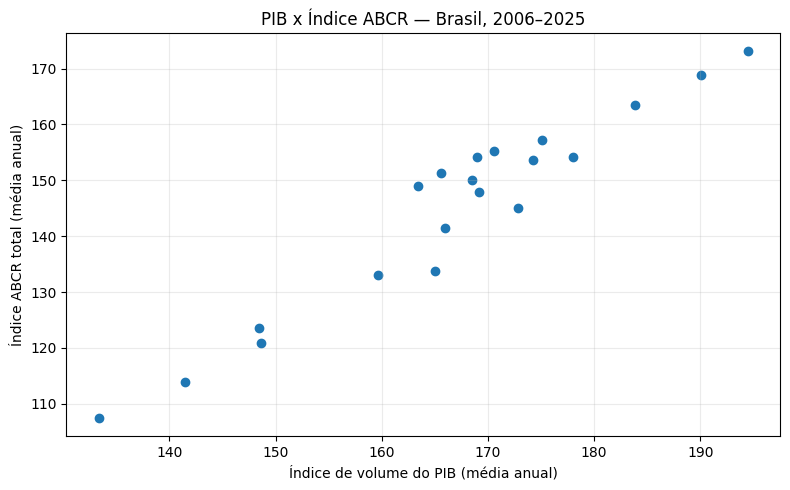

In [4]:
X_todos = np.array([[linha[1]] for linha in dados_anuais], dtype=float)
y_todos = np.array([linha[2] for linha in dados_anuais], dtype=float)

correlacao = float(np.corrcoef(X_todos[:, 0], y_todos)[0, 1])
print(f"Correlação de Pearson: {correlacao:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_todos[:, 0], y_todos)
plt.xlabel("Índice de volume do PIB (média anual)")
plt.ylabel("Índice ABCR total (média anual)")
plt.title("PIB x Índice ABCR — Brasil, 2006–2025")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "dispersao_pib_abcr.png", dpi=160)
plt.show()


A correlação obtida é **0.9641**, indicando uma associação linear positiva forte no período analisado. Em geral, anos com maior índice de volume do PIB também apresentam maior Índice ABCR.

Isso não significa que o aumento do PIB cause diretamente o aumento do fluxo de veículos. Correlação alta, isoladamente, não demonstra causa e efeito.


## 3. Treinamento da regressão linear

A divisão segue exatamente a ordem cronológica pedida:

- **Treino:** 2006 a 2021, 16 anos;
- **Teste:** 2022 a 2025, 4 anos.

Não há embaralhamento dos registros.


In [5]:
X = np.array([[linha[1]] for linha in dados_anuais], dtype=float)
y = np.array([linha[2] for linha in dados_anuais], dtype=float)

X_treino = X[:16]
y_treino = y[:16]

X_teste = X[16:]
y_teste = y[16:]

modelo = LinearRegression()
modelo.fit(X_treino, y_treino)

y_previsto = modelo.predict(X_teste)

print(f"Coeficiente angular: {modelo.coef_[0]:.6f}")
print(f"Intercepto: {modelo.intercept_:.6f}")
print()
print(f"Equação: ABCR_indice = {modelo.intercept_:.4f} + {modelo.coef_[0]:.4f} × PIB_indice")


Coeficiente angular: 1.214533
Intercepto: -56.785600

Equação: ABCR_indice = -56.7856 + 1.2145 × PIB_indice


## 4. Avaliação

Serão usadas três métricas:

- **MAE:** erro absoluto médio. Mostra quantos pontos de índice, em média, separam previsão e valor real.
- **MSE:** erro quadrático médio. Penaliza mais fortemente erros maiores.
- **R²:** mede quanto da variação observada no conjunto de teste é explicada pelo modelo. Quanto mais próximo de 1, melhor o ajuste no teste.


In [6]:
mae = mean_absolute_error(y_teste, y_previsto)
mse = mean_squared_error(y_teste, y_previsto)
r2 = r2_score(y_teste, y_previsto)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R²:  {r2:.4f}")
print()

print(f"{'Ano':<6}{'Observado':>14}{'Previsto':>14}{'Erro':>14}")
print("-" * 48)

linhas_teste = dados_anuais[16:]

for (ano, pib, observado), previsto in zip(linhas_teste, y_previsto):
    erro = observado - previsto
    print(f"{ano:<6}{observado:>14.4f}{previsto:>14.4f}{erro:>14.4f}")

with open(PASTA_RESULTADOS / "previsoes_teste.csv", "w", newline="", encoding="utf-8") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["Ano", "PIB_indice", "ABCR_observado", "ABCR_previsto", "Erro_observado_menos_previsto"])
    for (ano, pib, observado), previsto in zip(linhas_teste, y_previsto):
        escritor.writerow([ano, f"{pib:.6f}", f"{observado:.6f}", f"{previsto:.6f}", f"{observado-previsto:.6f}"])


with open(PASTA_RESULTADOS / "metricas.csv", "w", newline="", encoding="utf-8") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["Metrica", "Valor"])
    escritor.writerow(["Correlacao_Pearson_20_anos", f"{correlacao:.6f}"])
    escritor.writerow(["MAE_teste", f"{mae:.6f}"])
    escritor.writerow(["MSE_teste", f"{mse:.6f}"])
    escritor.writerow(["R2_teste", f"{r2:.6f}"])
    escritor.writerow(["Coeficiente_angular", f"{modelo.coef_[0]:.6f}"])
    escritor.writerow(["Intercepto", f"{modelo.intercept_:.6f}"])


MAE: 4.9489
MSE: 25.9502
R²:  0.4849

Ano        Observado      Previsto          Erro
------------------------------------------------
2022        154.1235      159.4589       -5.3354
2023        163.4908      166.4667       -2.9759
2024        168.8758      174.1001       -5.2243
2025        173.1204      179.3803       -6.2598


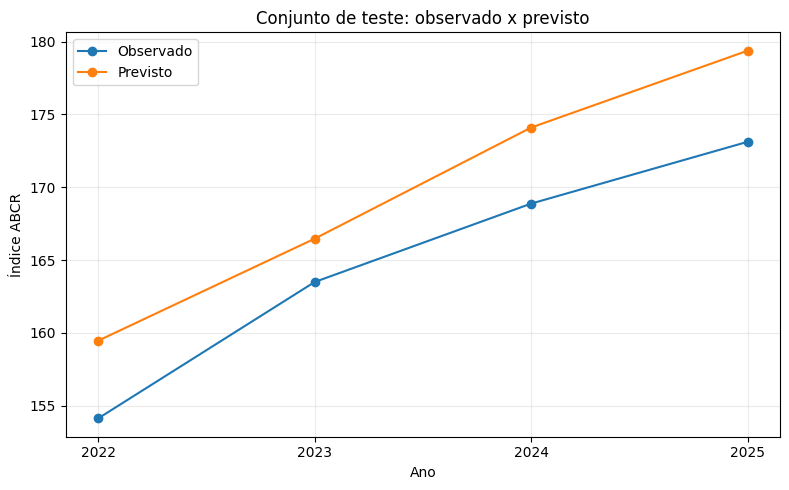

In [7]:
anos_teste = [linha[0] for linha in linhas_teste]
observados = [linha[2] for linha in linhas_teste]

plt.figure(figsize=(8, 5))
plt.plot(anos_teste, observados, marker="o", label="Observado")
plt.plot(anos_teste, y_previsto, marker="o", label="Previsto")
plt.xlabel("Ano")
plt.ylabel("Índice ABCR")
plt.title("Conjunto de teste: observado x previsto")
plt.xticks(anos_teste)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig(PASTA_RESULTADOS / "observado_vs_previsto.png", dpi=160)
plt.show()


### Interpretação dos resultados

O **MAE foi 4.9489**, portanto as previsões ficaram, em média, cerca de **4.95 pontos de índice** distantes dos valores observados.

O **MSE foi 25.9502**. Como essa métrica eleva os erros ao quadrado, diferenças maiores têm peso maior no resultado.

O **R² foi 0.4849**. Nos quatro anos reservados para teste, o modelo explica aproximadamente **48.5%** da variação observada do Índice ABCR.

As previsões ficaram relativamente próximas da ordem de grandeza dos valores reais, mas houve uma tendência de superestimação de 2022 a 2025. Isso reforça que, embora a relação histórica entre as duas séries seja forte, o PIB sozinho não é suficiente para explicar toda a variação do fluxo de veículos.


## 5. Dificuldades encontradas e soluções

1. **Frequências diferentes:** o PIB é trimestral e o ABCR é mensal. A solução foi transformar as duas séries em médias anuais.
2. **Escolha da série correta:** a planilha da ABCR contém série original e dessazonalizada. Foi usada a **série original**, coluna **TOTAL**, como solicitado.
3. **Bases numéricas diferentes:** o PIB usa média de 1995 = 100 e o ABCR usa 1999 = 100. Isso não impede a regressão, porque a análise mede associação entre os índices e não exige que eles tenham a mesma base.
4. **Ordem temporal:** foi evitado o embaralhamento. A separação treino/teste foi feita por posição cronológica.
5. **Revisões das séries:** dados macroeconômicos podem ser revisados. Os arquivos originais usados nesta análise foram mantidos na pasta `dados_originais/`.


## Conclusão

Entre 2006 e 2025, o índice de volume do PIB e o Índice ABCR apresentaram correlação positiva forte, de aproximadamente **0.964**.

A regressão linear treinada com os dados de 2006 a 2021 apresentou, no teste de 2022 a 2025:

- **MAE:** 4.949
- **MSE:** 25.950
- **R²:** 0.485

O resultado sugere que o fluxo de veículos em rodovias pedagiadas acompanha de forma relevante a atividade econômica, mas também evidencia que outras variáveis influenciam o Índice ABCR. Assim, a regressão é útil para descrever a relação e produzir estimativas simples, mas não deve ser interpretada como prova de causalidade nem como modelo completo do comportamento do tráfego.
